# Análisis de Simulación en Lazo Cerrado con Python

Para analizar el comportamiento interno de nuestro sistema, no podemos usar una simple reducción matemática del lazo. Necesitamos modelar la arquitectura completa del sistema de control.

## Diagrama de Bloques del Sistema

El siguiente diagrama ilustra la arquitectura de la red que estamos construyendo con la librería `control.interconnect`. En lugar de colapsar todo en una sola ecuación, mantenemos el acceso a las señales **$e(t)$** (Error) y **$u(t)$** (Esfuerzo de control).



## Explicación del Código Paso a Paso

El código en Python utiliza el módulo `interconnect` para recrear exactamente el diagrama de bloques superior. Así es como funciona cada sección:

### 1. Definición de Modelos ($G(s)$ y $C(s)$)
Primero, definimos las funciones de transferencia estándar usando `ct.tf()`. Aquí declaramos las matemáticas puras de nuestra planta (levitador) y el controlador PI. En este punto, los bloques "flotan" de manera independiente; no saben que pertenecen a un lazo de control.

### 2. Conversión a Sistemas I/O (`ct.tf2io`)
Este es el paso crítico. Para conectar los bloques como piezas de Lego, necesitamos "nombrar los cables" de entrada y salida:
* **Planta:** Le decimos que su entrada se llama `u` (el PWM) y su salida `y` (la altura).
* **Controlador:** Le decimos que recibe `e` (el error) y expulsa `u` (el PWM).

### 3. El Punto de Suma (`ct.summing_junction`)
Representa el círculo con el símbolo de más (+) y menos (-) en el diagrama.
```python
sumblk = ct.summing_junction(inputs=['r', '-y'], output='e')

In [ ]:
from IPython.display import HTML, display

diagrama = """
<div align="center">
  <svg width="600" height="180" xmlns="http://www.w3.org/2000/svg">
    <defs>
      <marker id="arrow" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
        <path d="M 0 0 L 10 5 L 0 10 z" fill="#333" />
      </marker>
    </defs>

    <text x="10" y="85" font-family="sans-serif" font-size="16" font-weight="bold" fill="#0056b3">r(t)</text>
    <line x1="45" y1="80" x2="80" y2="80" stroke="#333" stroke-width="2" marker-end="url(#arrow)" />

    <circle cx="100" cy="80" r="16" stroke="#333" stroke-width="2" fill="#fff" />
    <text x="75" y="65" font-family="sans-serif" font-size="18" fill="#28a745">+</text>
    <text x="110" y="115" font-family="sans-serif" font-size="20" fill="#dc3545">-</text>

    <text x="125" y="70" font-family="sans-serif" font-size="16" font-weight="bold" fill="#28a745">e(t)</text>
    <line x1="116" y1="80" x2="170" y2="80" stroke="#333" stroke-width="2" marker-end="url(#arrow)" />

    <rect x="170" y="50" width="90" height="60" rx="5" stroke="#333" stroke-width="2" fill="#e9ecef" />
    <text x="195" y="85" font-family="sans-serif" font-size="18">C(s)</text>

    <text x="275" y="70" font-family="sans-serif" font-size="16" font-weight="bold" fill="#fd7e14">u(t)</text>
    <line x1="260" y1="80" x2="340" y2="80" stroke="#333" stroke-width="2" marker-end="url(#arrow)" />

    <rect x="340" y="50" width="90" height="60" rx="5" stroke="#333" stroke-width="2" fill="#e9ecef" />
    <text x="365" y="85" font-family="sans-serif" font-size="18">G(s)</text>

    <line x1="430" y1="80" x2="530" y2="80" stroke="#333" stroke-width="2" marker-end="url(#arrow)" />
    <text x="540" y="85" font-family="sans-serif" font-size="16" font-weight="bold" fill="#6f42c1">y(t)</text>

    <line x1="480" y1="80" x2="480" y2="150" stroke="#333" stroke-width="2" />
    <line x1="480" y1="150" x2="100" y2="150" stroke="#333" stroke-width="2" />
    <line x1="100" y1="150" x2="100" y2="96" stroke="#333" stroke-width="2" marker-end="url(#arrow)" />
  </svg>
</div>
"""
display(HTML(diagrama))

In [ ]:
!pip install control

/usr/local/lib/python3.12/dist-packages/control/statesp.py:1865: FutureWarning: tf2io() is deprecated; use tf2ss() or tf()
  warn("tf2io() is deprecated; use tf2ss() or tf()", FutureWarning)


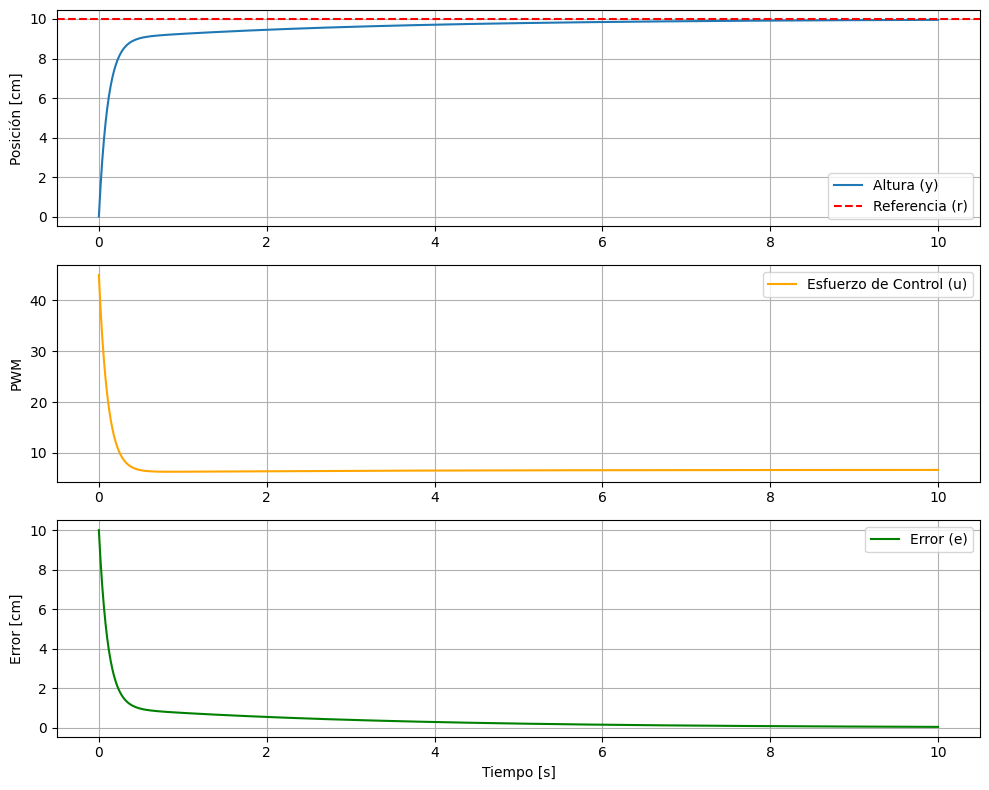

In [ ]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir los modelos matemáticos
# Ejemplo: Planta G(s) de primer orden y Controlador C(s) PI
G = ct.tf([1.5], [0.8, 1])     # Reemplazar con su planta identificada
C = ct.tf([4.5, 1.588], [1, 0]) # Kp = 4.5, Ki = 1.588

# 2. Convertir a sistemas I/O con señales nombradas
plant = ct.tf2io(G, name='planta', inputs='u', outputs='y')
controller = ct.tf2io(C, name='controlador', inputs='e', outputs='u')

# 3. Crear el punto de suma para el error: e = r - y
sumblk = ct.summing_junction(inputs=['r', '-y'], output='e')

# 4. Interconectar el sistema
# Especificamos que 'r' (referencia) es la entrada global.
# Especificamos que queremos registrar 'y', 'u' y 'e' como salidas.
sys_closed = ct.interconnect(
    [plant, controller, sumblk],
    inplist=['r'],
    outlist=['y', 'u', 'e']
)

# 5. Simular la respuesta al escalón (Ej: cambio de 10 cm en la referencia)
time = np.linspace(0, 10, 500)
t, outputs = ct.step_response(sys_closed, T=time)

# Escalar por la magnitud del escalon (10)
y = np.squeeze(outputs[0]) * 10
u = np.squeeze(outputs[1]) * 10
e = np.squeeze(outputs[2]) * 10

# 6. Graficar los resultados
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t, y, label='Altura (y)')
plt.axhline(10, color='r', linestyle='--', label='Referencia (r)')
plt.ylabel('Posición [cm]')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, u, color='orange', label='Esfuerzo de Control (u)')
plt.ylabel('PWM')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, e, color='green', label='Error (e)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Error [cm]')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()